# cdslib — OIS curve bootstrapping demo

Bootstrap a RUONIA zero curve from bid/ask OIS quotes and explore the
fitted curve, the forward curve (smoothness), and the per-quote
adjustments. Edit the quotes / budget in the last cell and re-run.

The bootstrap uses **mids as the baseline**, smooths the forward only
enough to remove genuine kinks (L-curve elbow), and never lets the average
absolute adjustment exceed the cap (default **15 bps**).

In [18]:
%matplotlib inline
from datetime import date

import numpy as np
import matplotlib.pyplot as plt

from cdslib import OISQuote, OISGenerator, bootstrap

TRADE = date(2024, 6, 3)
gen = OISGenerator.load_default()

# Bid/ask in percentage points (14.35 == 14.35%). Deliberately a bit noisy.
QUOTES = [
    OISQuote("RUONIA", "1m", 13.95, 13.98),
    OISQuote("RUONIA", "2m", 13.95, 13.98),
    OISQuote("RUONIA", "3m", 13.89, 14.04),
    OISQuote("RUONIA", "6m", 13.76, 13.91),
    OISQuote("RUONIA", "9m", 13.78, 13.93),
    OISQuote("RUONIA", "1y", 13.60, 13.75),
    OISQuote("RUONIA", "2y", 12.82, 12.97),
    OISQuote("RUONIA", "3y", 12.85, 13.00),
    OISQuote("RUONIA", "4y", 12.95, 13.10),
    OISQuote("RUONIA", "5y", 13.12, 13.19),
    OISQuote("RUONIA", "7y", 13.25, 13.40),
    OISQuote("RUONIA", "10y", 13.38, 13.50),
]

## 1. Run the bootstrap

In [19]:
res = bootstrap(QUOTES, TRADE)
print(f"rate_index = {res.rate_index}")
print(f"trade = {res.trade_date}   spot = {res.spot_date}")
print(
    f"nodes = {len(res.points)} (monthly)   last tenor = {res.points[-1].tenor_days} days"
)
print(f"smoothing lambda = {res.smoothing_lambda:.4g}")
print(f"average adjustment = {res.average_adjustment_bps:.2f} bps")

rate_index = RUONIA
trade = 2024-06-03   spot = 2024-06-04
nodes = 120 (monthly)   last tenor = 3653 days
smoothing lambda = 0.0711
average adjustment = 2.12 bps


## 2. Per-quote adjustments
How each mid was repriced by the fitted curve.

In [20]:
print(f"{'tenor':>5} {'mid %':>8} {'model %':>8} {'adj bps':>8} {'in spread':>10}")
for f in res.fits:
    print(
        f"{f.tenor:>5} {f.mid_rate*100:>8.3f} {f.model_rate*100:>8.3f} "
        f"{f.adjustment_bps:>+8.1f} {str(f.within_spread):>10}"
    )

tenor    mid %  model %  adj bps  in spread
   1m   13.965   13.964     -0.1       True
   2m   13.965   13.964     -0.1       True
   3m   13.965   13.947     -1.8       True
   6m   13.835   13.864     +2.9       True
   9m   13.855   13.789     -6.6       True
   1y   13.675   13.700     +2.5       True
   2y   12.895   12.989     +9.4      False
   3y   12.925   12.921     -0.4       True
   4y   13.025   13.029     +0.4       True
   5y   13.155   13.150     -0.5       True
   7y   13.325   13.317     -0.8       True
  10y   13.440   13.440     +0.0       True


## 3. Helpers for plotting

In [21]:
def zero_pct(result):
    t = np.array([d for d, _ in result.as_tuples()]) / 365.0
    z = np.array([r for _, r in result.as_tuples()]) * 100.0
    return t, z


def forward_pct(result):
    days = np.array([0.0] + [d for d, _ in result.as_tuples()])
    zr = np.array([0.0] + [r for _, r in result.as_tuples()])
    t = days / 365.0
    integrated = zr * t
    fwd = np.diff(integrated) / np.diff(t)
    centres = 0.5 * (t[1:] + t[:-1])
    return centres, fwd * 100.0


def quote_points(result, quotes):
    xs, mids, models = [], [], []
    for fit, quote in zip(result.fits, quotes):
        swap = gen.generate(quote.rate_index, quote.tenor, result.trade_date)
        xs.append((swap.maturity_date - result.spot_date).days / 365.0)
        mids.append(fit.mid_rate * 100.0)
        models.append(fit.model_rate * 100.0)
    return xs, mids, models

## 4. Zero curve vs quoted par rates
The fitted continuously-compounded zero curve, with the quoted mids and the
model-repriced par rates at each quote maturity.

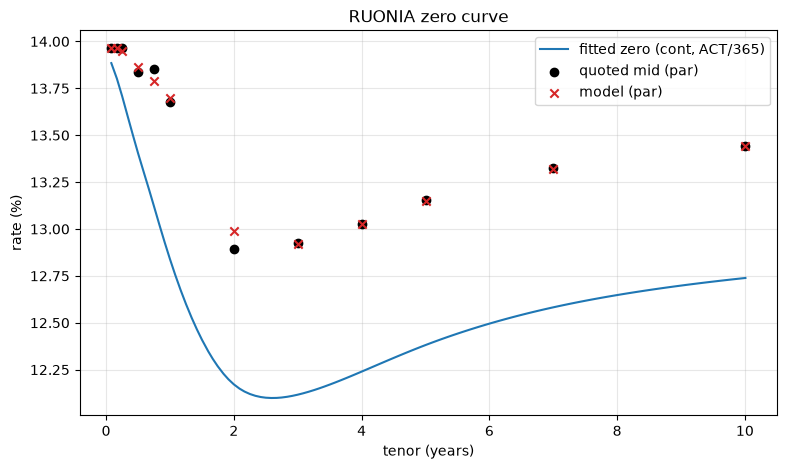

In [22]:
t, z = zero_pct(res)
xs, mids, models = quote_points(res, QUOTES)

plt.figure(figsize=(9, 5))
plt.plot(t, z, color="C0", label="fitted zero (cont, ACT/365)")
plt.scatter(xs, mids, color="black", zorder=3, label="quoted mid (par)")
plt.scatter(xs, models, color="C3", marker="x", zorder=3, label="model (par)")
plt.xlabel("tenor (years)")
plt.ylabel("rate (%)")
plt.title("RUONIA zero curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 5. Forward curve (the thing being smoothed)
Piecewise-constant monthly forward rates. The bootstrap minimises the
curvature of this curve.

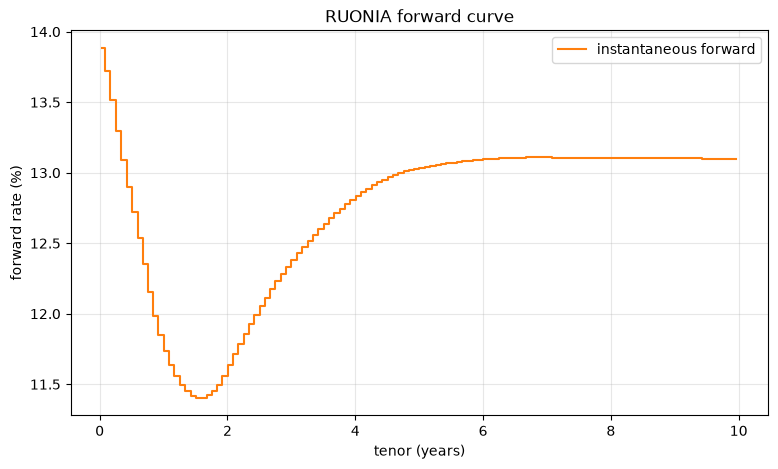

In [23]:
cx, cf = forward_pct(res)

plt.figure(figsize=(9, 5))
plt.step(cx, cf, where="mid", color="C1", label="instantaneous forward")
plt.xlabel("tenor (years)")
plt.ylabel("forward rate (%)")
plt.title("RUONIA forward curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 6. Adjustments per quote
Bars are model-minus-mid in bps; dashed line is the average (the capped
quantity).

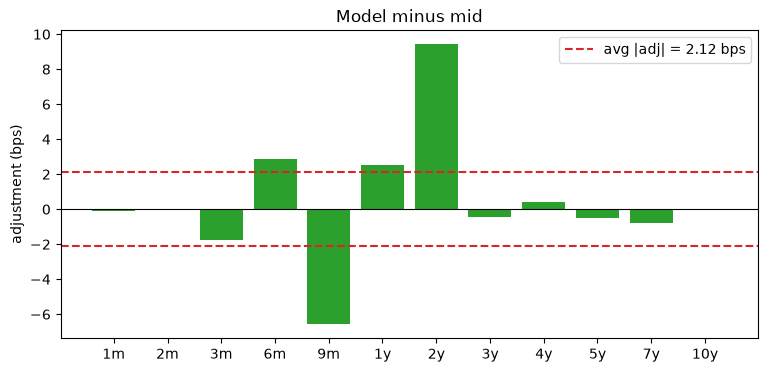

In [24]:
tenors = [f.tenor for f in res.fits]
adjustments = [f.adjustment_bps for f in res.fits]

plt.figure(figsize=(9, 4))
plt.bar(tenors, adjustments, color="C2")
plt.axhline(0.0, color="black", linewidth=0.8)
plt.axhline(
    res.average_adjustment_bps,
    color="C3",
    linestyle="--",
    label=f"avg |adj| = {res.average_adjustment_bps:.2f} bps",
)
plt.axhline(-res.average_adjustment_bps, color="C3", linestyle="--")
plt.ylabel("adjustment (bps)")
plt.title("Model minus mid")
plt.legend()
plt.show()

## 7. Effect of the adjustment budget
A tiny cap forces the curve to track the (noisy) mids; a larger cap lets the
forward smooth out. Note how little smoothing is needed here — the default
does not spend the whole 15 bps.

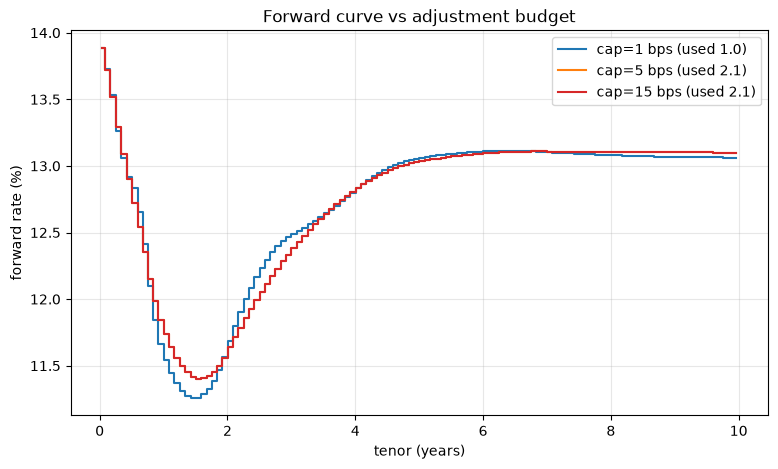

In [25]:
plt.figure(figsize=(9, 5))
for cap, colour in [(1.0, "C0"), (5.0, "C1"), (15.0, "C3")]:
    r = bootstrap(QUOTES, TRADE, max_avg_adjustment_bps=cap)
    cx, cf = forward_pct(r)
    plt.step(
        cx,
        cf,
        where="mid",
        color=colour,
        label=f"cap={cap:g} bps (used {r.average_adjustment_bps:.1f})",
    )
plt.xlabel("tenor (years)")
plt.ylabel("forward rate (%)")
plt.title("Forward curve vs adjustment budget")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 8. Playground
Edit the quotes and the budget, then re-run.

lambda=0.0711  avg_adj=2.12 bps  cap=15  nodes=120


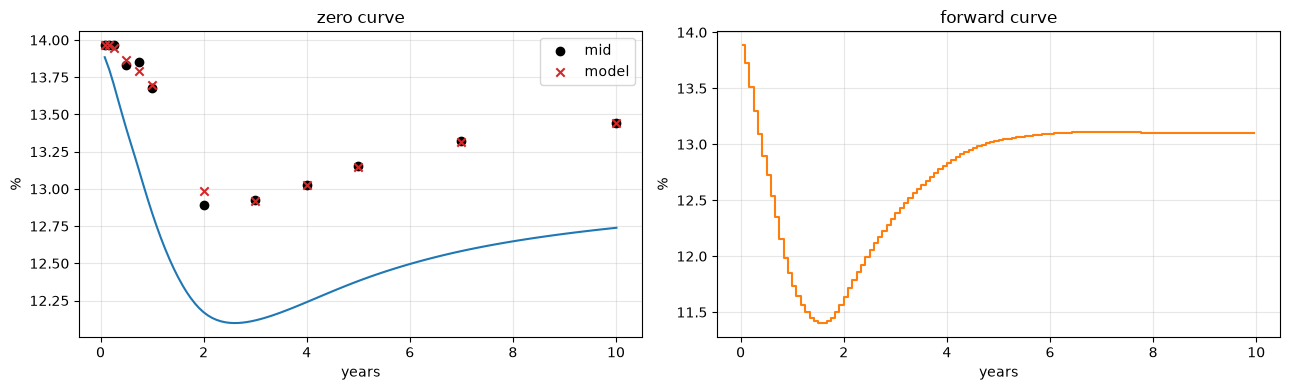

In [26]:
def show_bootstrap(quotes, max_avg_adjustment_bps=15.0):
    result = bootstrap(quotes, TRADE, max_avg_adjustment_bps=max_avg_adjustment_bps)
    print(
        f"lambda={result.smoothing_lambda:.4g}  "
        f"avg_adj={result.average_adjustment_bps:.2f} bps  "
        f"cap={max_avg_adjustment_bps:g}  nodes={len(result.points)}"
    )
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    t, z = zero_pct(result)
    xs, mids, models = quote_points(result, quotes)
    axes[0].plot(t, z, color="C0")
    axes[0].scatter(xs, mids, color="black", zorder=3, label="mid")
    axes[0].scatter(xs, models, color="C3", marker="x", zorder=3, label="model")
    axes[0].set_title("zero curve")
    axes[0].set_xlabel("years")
    axes[0].set_ylabel("%")
    axes[0].grid(alpha=0.3)
    axes[0].legend()
    cx, cf = forward_pct(result)
    axes[1].step(cx, cf, where="mid", color="C1")
    axes[1].set_title("forward curve")
    axes[1].set_xlabel("years")
    axes[1].set_ylabel("%")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return result


_ = show_bootstrap(QUOTES, max_avg_adjustment_bps=15.0)